APPENDIX C: IMPROVED LOCALIZATION TEST
Lattice: N=201, Ticks: 500

--- A. Linear real ---
Sequence     |   IPR(500) |   <r^2>(500) |  Peak(500) |   TRB(500)
--------------------------------------------------------------------
All-Ones     |    0.00873 |      1059.19 |    0.00892 |     0.0000
Fibonacci    |    0.01162 |       590.63 |    0.01163 |     0.0000
Lucas        |    0.01209 |       544.76 |    0.01210 |     0.0000
Linear       |    0.01127 |       628.84 |    0.01128 |     0.0000

--- B. Linear + mod 9 ---
Sequence     |   IPR(500) |   <r^2>(500) |  Peak(500) |   TRB(500)
--------------------------------------------------------------------
All-Ones     |    0.00869 |      3209.27 |    8.00000 |     0.0000
Fibonacci    |    0.00973 |      3490.21 |    8.00000 |     0.0000
Lucas        |    0.01040 |      3312.72 |    8.00000 |     0.0000
Linear       |    0.00824 |      2621.38 |    8.00000 |     0.0000

--- C. Full Fano ---
Sequence     |   IPR(500) |   <r^2>(500) |  Peak(500)

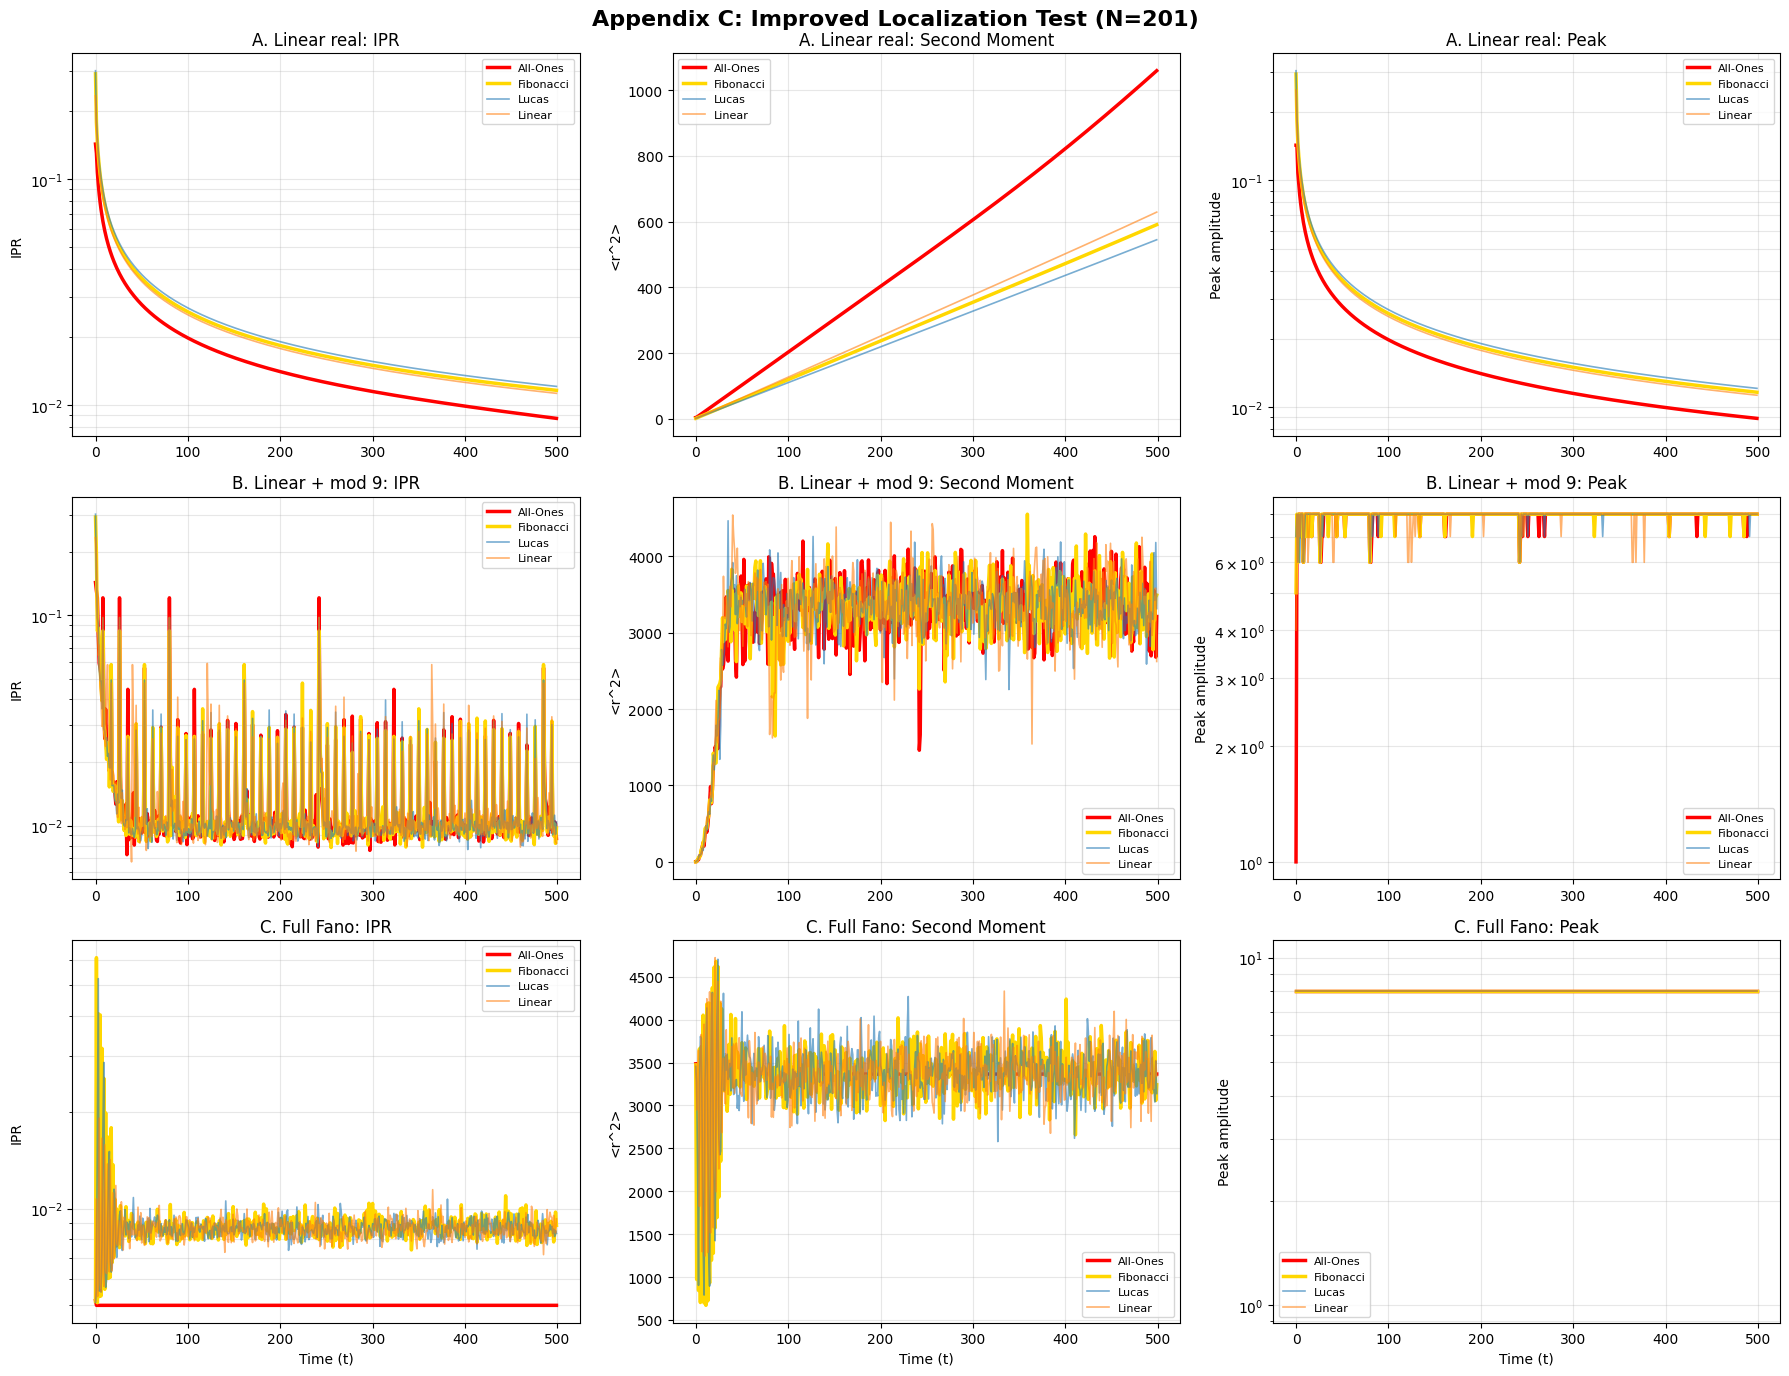


✓ Saved: appendix_c_improved_test.png


In [3]:
"""
Appendix C: Information-Theoretic Death of All-Ones (Improved Test)
====================================================================
Fixes:
- N=201 (large enough that diffusion does not saturate in 500 ticks)
- Tracks RATE metrics: IPR, second moment <r^2>, peak amplitude
- Three variants:
    A. Linear real (isolates weight effect)
    B. Linear + mod 9 (modular scrambling)
    C. Full Fano automaton (mod 9 + Fano check)

Prediction: All-Ones diffuses fastest. Fibonacci preserves
localization longest among asymmetric sequences.
"""

import numpy as np
import matplotlib.pyplot as plt

sequences = {
    'All-Ones':     [1, 1, 1, 1, 1, 1, 1],
    'Fibonacci':    [1, 2, 3, 5, 3, 2, 1],
    'Lucas':        [1, 3, 4, 7, 4, 3, 1],
    'Linear':       [1, 2, 3, 4, 3, 2, 1],
}

N = 201
CENTER = N // 2
N_TICKS = 500
B = 9

# =============================================================================
# VARIANT A: Linear real (normalized)
# =============================================================================
def step_linear_real(state, weights):
    total_w = sum(weights)
    new_state = np.zeros_like(state)
    for i in range(len(state)):
        s = 0.0
        for k in range(-3, 4):
            j = (i + k) % len(state)
            s += weights[k+3] * state[j]
        new_state[i] = s / total_w
    return new_state

# =============================================================================
# VARIANT B: Linear + mod 9
# =============================================================================
def step_linear_mod9(state, weights):
    new_state = np.zeros_like(state)
    for i in range(len(state)):
        s = 0
        for k in range(-3, 4):
            j = (i + k) % len(state)
            s += weights[k+3] * state[j]
        new_state[i] = s % B
    return new_state

# =============================================================================
# VARIANT C: Full Fano automaton (mod 9 + Fano check)
# =============================================================================
def step_full_fano(state, weights):
    new_state = np.zeros_like(state)
    for i in range(len(state)):
        s = 0
        for k in range(-3, 4):
            j = (i + k) % len(state)
            s += weights[k+3] * state[j]
        if s % 7 == 0:
            new_state[i] = B - 1
        else:
            new_state[i] = s % B
    return new_state

# =============================================================================
# SIMULATION
# =============================================================================
def simulate(weights, step_fn, n_ticks=N_TICKS, initial_state=None):
    if initial_state is None:
        state = np.zeros(N)
        state[CENTER] = 1.0
        initial = np.zeros(N)
    else:
        state = initial_state.copy()
        initial = initial_state.copy()

    ipr_hist = []
    r2_hist = []
    peak_hist = []
    trb_hist = []

    x = np.arange(N) - CENTER

    for t in range(n_ticks):
        state = step_fn(state, weights)
        deviation = (state - initial).astype(float)

        s2 = np.sum(deviation**2)
        s4 = np.sum(deviation**4)

        ipr = s4 / (s2**2 + 1e-30)
        r2 = np.sum(x**2 * deviation**2) / (s2 + 1e-30)
        peak = np.max(np.abs(deviation))
        trb = np.sum(state == B - 1) / N if step_fn is step_full_fano else 0.0

        ipr_hist.append(ipr)
        r2_hist.append(r2)
        peak_hist.append(peak)
        trb_hist.append(trb)

    return {
        'ipr': np.array(ipr_hist),
        'r2': np.array(r2_hist),
        'peak': np.array(peak_hist),
        'trb': np.array(trb_hist),
    }

# =============================================================================
# RUN ALL THREE VARIANTS
# =============================================================================
print("=" * 80)
print("APPENDIX C: IMPROVED LOCALIZATION TEST")
print("=" * 80)
print(f"Lattice: N={N}, Ticks: {N_TICKS}")
print()

variants = {
    'A. Linear real':     step_linear_real,
    'B. Linear + mod 9':  step_linear_mod9,
    'C. Full Fano':       step_full_fano,
}

all_results = {}

for variant_name, step_fn in variants.items():
    print(f"--- {variant_name} ---")
    print(f"{'Sequence':<12} | {'IPR(500)':>10} | {'<r^2>(500)':>12} | {'Peak(500)':>10} | {'TRB(500)':>10}")
    print("-" * 68)

    results = {}
    for name, w in sequences.items():
        res = simulate(w, step_fn)
        results[name] = res
        print(f"{name:<12} | {res['ipr'][-1]:>10.5f} | {res['r2'][-1]:>12.2f} | {res['peak'][-1]:>10.5f} | {res['trb'][-1]:>10.4f}")
    all_results[variant_name] = results
    print()

# =============================================================================
# KEY RATIOS
# =============================================================================
print("=" * 80)
print("KEY RATIOS (Fibonacci / All-Ones)")
print("=" * 80)
print(f"{'Variant':<20} | {'IPR ratio':>12} | {'<r^2> ratio':>12} | {'Peak ratio':>12}")
print("-" * 66)

for variant_name, results in all_results.items():
    fib = results['Fibonacci']
    ao = results['All-Ones']
    ipr_ratio = fib['ipr'][-1] / ao['ipr'][-1]
    r2_ratio = fib['r2'][-1] / ao['r2'][-1]
    peak_ratio = fib['peak'][-1] / ao['peak'][-1]
    print(f"{variant_name:<20} | {ipr_ratio:>12.3f} | {r2_ratio:>12.3f} | {peak_ratio:>12.3f}")

print()
print("Interpretation:")
print("  IPR ratio > 1: Fibonacci more localized")
print("  <r^2> ratio < 1: Fibonacci spreads less")
print("  Peak ratio > 1: Fibonacci preserves peak amplitude")

# =============================================================================
# ANALYTICAL PREDICTION
# =============================================================================
print()
print("=" * 80)
print("ANALYTICAL PREDICTION (linear diffusion)")
print("=" * 80)
print(f"{'Sequence':<12} | {'D':>8} | {'Peak ratio vs All-Ones':>24}")
print("-" * 50)

D_allones = 0.5 * sum(k**2 * w for k, w in zip(range(-3, 4), sequences['All-Ones'])) / sum(sequences['All-Ones'])

for name, w in sequences.items():
    D = 0.5 * sum(k**2 * wk for k, wk in zip(range(-3, 4), w)) / sum(w)
    ratio = np.sqrt(D_allones / D)
    print(f"{name:<12} | {D:>8.3f} | {ratio:>24.3f}")

# =============================================================================
# VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Appendix C: Improved Localization Test (N=201)', fontsize=16, fontweight='bold')

for row, (variant_name, results) in enumerate(all_results.items()):
    for name in sequences:
        color = 'red' if name == 'All-Ones' else ('gold' if name == 'Fibonacci' else None)
        lw = 2.5 if name in ['All-Ones', 'Fibonacci'] else 1.2
        alpha = 1.0 if name in ['All-Ones', 'Fibonacci'] else 0.6

        axes[row, 0].plot(results[name]['ipr'], linewidth=lw, label=name, color=color, alpha=alpha)
        axes[row, 1].plot(results[name]['r2'], linewidth=lw, label=name, color=color, alpha=alpha)
        axes[row, 2].plot(results[name]['peak'], linewidth=lw, label=name, color=color, alpha=alpha)

    axes[row, 0].set_yscale('log')
    axes[row, 0].set_ylabel('IPR')
    axes[row, 0].set_title(f'{variant_name}: IPR')
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].grid(True, alpha=0.3, which='both')

    axes[row, 1].set_ylabel('<r^2>')
    axes[row, 1].set_title(f'{variant_name}: Second Moment')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(True, alpha=0.3)

    axes[row, 2].set_yscale('log')
    axes[row, 2].set_ylabel('Peak amplitude')
    axes[row, 2].set_title(f'{variant_name}: Peak')
    axes[row, 2].legend(fontsize=8)
    axes[row, 2].grid(True, alpha=0.3, which='both')

for ax in axes[-1, :]:
    ax.set_xlabel('Time (t)')

plt.tight_layout()
plt.savefig('appendix_c_improved_test.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: appendix_c_improved_test.png")